# CLEVR-with-masks dataset statistics

Per-scene object count, color, and shape distributions over the CLEVR-with-masks training split. Color and shape labels live in the raw TFRecord (not retained by `convert_tfrecords.py`), so we parse the source file directly.

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

sns.set_theme(context='paper', style='whitegrid', font_scale=1.1)

TFRECORD = 'clevr_with_masks_clevr_with_masks_train.tfrecords'

# Per the DeepMind Multi-Object Datasets release
COLOR_NAMES = ['gray', 'red', 'blue', 'green', 'brown', 'purple', 'cyan', 'yellow']
SHAPE_NAMES = ['cube', 'sphere', 'cylinder']  # label 0 is the null/background slot

In [8]:
def parse_features(raw):
    ex = tf.train.Example()
    ex.ParseFromString(raw.numpy())
    f = ex.features.feature
    visibility = np.array(f['visibility'].float_list.value, dtype=np.float32)
    # color and shape are stored as 11 single-byte entries (label per slot)
    color = np.frombuffer(b''.join(f['color'].bytes_list.value), dtype=np.uint8)
    shape = np.frombuffer(b''.join(f['shape'].bytes_list.value), dtype=np.uint8)
    return visibility, color, shape

object_counts, colors, shapes = [], [], []
ds = tf.data.TFRecordDataset(TFRECORD, compression_type='GZIP')
for raw in ds:
    vis, col, shp = parse_features(raw)
    # slot 0 is the background (visibility=1, label=0); real objects have label > 0
    is_object = (vis > 0.5) & (shp > 0)
    object_counts.append(int(is_object.sum()))
    colors.extend(col[is_object].tolist())
    shapes.extend(shp[is_object].tolist())

print(f'Scenes parsed: {len(object_counts):,}')
print(f'Visible objects: {len(colors):,}')

Scenes parsed: 100,000
Visible objects: 649,378


2026-05-04 19:05:16.762692: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


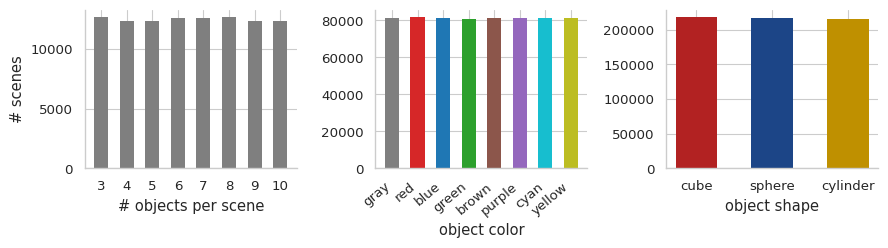

In [9]:
import numpy as np

# label vectors
color_labels = [COLOR_NAMES[c - 1] if 1 <= c <= 8 else 'unknown' for c in colors]
shape_labels = [SHAPE_NAMES[s - 1] if 1 <= s <= 3 else 'unknown' for s in shapes]

# palettes
gray = '#7f7f7f'
color_palette = {
    'gray':   '#7f7f7f', 'red':    '#d62728', 'blue':   '#1f77b4',
    'green':  '#2ca02c', 'brown':  '#8c564b', 'purple': '#9467bd',
    'cyan':   '#17becf', 'yellow': '#bcbd22',
}
shape_palette = {'cube': '#b22222', 'sphere': '#1c4587', 'cylinder': '#bf9000'}

bar_width = 0.55
fig, axes = plt.subplots(1, 3, figsize=(9, 2.6))

# 1. object counts
counts = np.array(object_counts)
xs = np.arange(counts.min(), counts.max() + 1)
ys = np.array([(counts == x).sum() for x in xs])
axes[0].bar(xs, ys, width=bar_width, color=gray, edgecolor='none')
axes[0].set_xticks(xs)
axes[0].set_xlabel('# objects per scene')
axes[0].set_ylabel('# scenes')

# 2. colors
ys2 = [color_labels.count(name) for name in COLOR_NAMES]
axes[1].bar(np.arange(len(COLOR_NAMES)), ys2, width=bar_width,
            color=[color_palette[c] for c in COLOR_NAMES], edgecolor='none')
axes[1].set_xticks(np.arange(len(COLOR_NAMES)))
axes[1].set_xticklabels(COLOR_NAMES, rotation=40, ha='right')
axes[1].set_xlabel('object color')

# 3. shapes
ys3 = [shape_labels.count(name) for name in SHAPE_NAMES]
axes[2].bar(np.arange(len(SHAPE_NAMES)), ys3, width=bar_width,
            color=[shape_palette[s] for s in SHAPE_NAMES], edgecolor='none')
axes[2].set_xticks(np.arange(len(SHAPE_NAMES)))
axes[2].set_xticklabels(SHAPE_NAMES)
axes[2].set_xlabel('object shape')

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()
